In [6]:
# Imports and GPU setup
import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# GPU Settings
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()

print("All imports done!")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

All imports done!
GPU available: True
GPU name: Tesla T4


In [7]:
import os

# Find the correct dataset path
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/thedevastator/extended-stanford-natural-language-inference-dat/validation.csv
/kaggle/input/datasets/thedevastator/extended-stanford-natural-language-inference-dat/train.csv
/kaggle/input/datasets/thedevastator/extended-stanford-natural-language-inference-dat/test.csv


In [8]:
# Cell 2 — Load dataset
DATA_PATH = "/kaggle/input/datasets/thedevastator/extended-stanford-natural-language-inference-dat"

train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
val_df   = pd.read_csv(f"{DATA_PATH}/validation.csv")
test_df  = pd.read_csv(f"{DATA_PATH}/test.csv")

# Map integer labels to strings
label_map_int = {0: "entailment", 1: "neutral", 2: "contradiction"}
for df in [train_df, val_df, test_df]:
    df["label_str"] = df["label"].map(label_map_int)
    df.dropna(subset=["premise", "hypothesis", "label_str"], inplace=True)

# Subsample exactly 100K with fixed seed — must match across all variants
train_df = train_df.sample(n=100_000, random_state=42).reset_index(drop=True)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")
print(f"Label distribution:\n{train_df['label_str'].value_counts()}")

Train: 100000
Val:   9842
Test:  9824
Label distribution:
label_str
entailment       33523
neutral          33330
contradiction    33147
Name: count, dtype: int64


In [9]:
MODEL_NAME = "microsoft/deberta-v3-base"

label2id = {"entailment": 0, "neutral": 1, "contradiction": 2}
id2label  = {0: "entailment", 1: "neutral", 2: "contradiction"}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded!")

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizer loaded!


In [10]:
class NLIDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=256):
        self.encodings = tokenizer(
            df["premise"].tolist(),
            df["hypothesis"].tolist(),
            truncation=True,
            max_length=max_length,
            padding="max_length"
        )
        self.labels = [label2id[l] for l in df["label_str"].tolist()]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = NLIDataset(train_df, tokenizer, max_length=256)
val_dataset   = NLIDataset(val_df,   tokenizer, max_length=256)
test_dataset  = NLIDataset(test_df,  tokenizer, max_length=256)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset:   {len(val_dataset)}")
print(f"Test dataset:  {len(test_dataset)}")

Train dataset: 100000
Val dataset:   9842
Test dataset:  9824


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)
model = model.float()

print("Model loaded!")
print(f"Parameters: {model.num_parameters():,}")

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias        

Model loaded!
Parameters: 184,424,451


In [13]:
# Cell 6 — Training arguments
training_args = TrainingArguments(
    output_dir                  = "/kaggle/working/variant_a",
    num_train_epochs            = 3,
    per_device_train_batch_size = 8,
    gradient_accumulation_steps = 4,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_steps                = 3090,
    fp16                        = True,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 3,
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    greater_is_better           = True,
    dataloader_num_workers      = 0,
    logging_steps               = 100,
    report_to                   = "none"
)
print("Training args ready!")

Training args ready!


In [14]:
# Cell 7 — Accuracy metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

print("Metrics ready!")

Metrics ready!


In [15]:
# Cell 8 — Full training
torch.cuda.empty_cache()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label
)
model = model.float()

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
)

print("Starting Variant A full training...")
print("Expected time: ~1.5 hours on T4\n")

trainer.train()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias        

Starting Variant A full training...
Expected time: ~1.5 hours on T4



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,5.862252,1.238398,0.750457
2,4.428961,0.995321,0.807559
3,3.775915,0.849693,0.841394


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4689, training_loss=5.410037837371208, metrics={'train_runtime': 11975.8693, 'train_samples_per_second': 25.05, 'train_steps_per_second': 0.392, 'total_flos': 3.9467720448e+16, 'train_loss': 5.410037837371208, 'epoch': 3.0})

In [16]:
import json

results = trainer.evaluate(test_dataset)

print("\n=== VARIANT A TEST RESULTS ===")
print(f"Validation Accuracy: 0.8414")
print(f"Test Accuracy:       {results['eval_accuracy']:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



=== VARIANT A TEST RESULTS ===
Validation Accuracy: 0.8414
Test Accuracy:       0.8336


In [17]:
from datasets import load_dataset

def make_dataset(premises, hypotheses, labels, tokenizer, max_length=256):
    class SimpleNLI(Dataset):
        def __init__(self):
            self.enc = tokenizer(
                premises, hypotheses,
                truncation=True, max_length=max_length,
                padding="max_length"
            )
            self.labels = labels
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
            item["labels"] = torch.tensor(self.labels[i])
            return item
    return SimpleNLI()

cross_results = {}

# SNLI test
print("Loading SNLI...")
snli = load_dataset("stanfordnlp/snli", split="test")
snli = snli.filter(lambda x: x["label"] != -1)
snli_ds = make_dataset(snli["premise"], snli["hypothesis"], snli["label"], tokenizer)
r = trainer.evaluate(snli_ds)
cross_results["SNLI Test"] = round(r["eval_accuracy"], 4)
print(f"SNLI Test: {cross_results['SNLI Test']:.4f}")

# MultiNLI
print("Loading MultiNLI...")
mnli = load_dataset("nyu-mll/multi_nli")
mnli_m_ds = make_dataset(
    mnli["validation_matched"]["premise"],
    mnli["validation_matched"]["hypothesis"],
    mnli["validation_matched"]["label"], tokenizer
)
mnli_mm_ds = make_dataset(
    mnli["validation_mismatched"]["premise"],
    mnli["validation_mismatched"]["hypothesis"],
    mnli["validation_mismatched"]["label"], tokenizer
)
r = trainer.evaluate(mnli_m_ds)
cross_results["MultiNLI Matched"] = round(r["eval_accuracy"], 4)
print(f"MultiNLI Matched: {cross_results['MultiNLI Matched']:.4f}")

r = trainer.evaluate(mnli_mm_ds)
cross_results["MultiNLI Mismatched"] = round(r["eval_accuracy"], 4)
print(f"MultiNLI Mismatched: {cross_results['MultiNLI Mismatched']:.4f}")

# ANLI
print("Loading ANLI...")
anli = load_dataset("facebook/anli")
for rd in ["r1", "r2", "r3"]:
    split = anli[f"test_{rd}"]
    ds = make_dataset(split["premise"], split["hypothesis"], split["label"], tokenizer)
    r = trainer.evaluate(ds)
    cross_results[f"ANLI {rd.upper()}"] = round(r["eval_accuracy"], 4)
    print(f"ANLI {rd.upper()}: {cross_results[f'ANLI {rd.upper()}']:.4f}")

print("\n=== FULL CROSS-DOMAIN RESULTS ===")
for k, v in cross_results.items():
    print(f"{k:30s}: {v*100:.2f}%")

Loading SNLI...


README.md: 0.00B [00:00, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/412k [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/413k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/19.6M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/550152 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

ValueError: text input must be of type `str` (single example), `list[str]` (batch or single pretokenized example) or `list[list[str]]` (batch of pretokenized examples) or `list[tuple[list[str], list[str]]]` (batch of pretokenized sequence pairs).

In [18]:
from datasets import load_dataset

def make_dataset(premises, hypotheses, labels, tokenizer, max_length=256):
    # Convert to lists explicitly
    premises   = list(premises)
    hypotheses = list(hypotheses)
    labels     = list(labels)
    
    class SimpleNLI(Dataset):
        def __init__(self):
            self.enc = tokenizer(
                premises, hypotheses,
                truncation=True, max_length=max_length,
                padding="max_length"
            )
            self.labels = labels
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
            item["labels"] = torch.tensor(self.labels[i])
            return item
    return SimpleNLI()

cross_results = {}

# SNLI test
print("Loading SNLI...")
snli = load_dataset("stanfordnlp/snli", split="test")
snli = snli.filter(lambda x: x["label"] != -1)
snli_ds = make_dataset(snli["premise"], snli["hypothesis"], snli["label"], tokenizer)
r = trainer.evaluate(snli_ds)
cross_results["SNLI Test"] = round(r["eval_accuracy"], 4)
print(f"SNLI Test: {cross_results['SNLI Test']:.4f}")

# MultiNLI
print("Loading MultiNLI...")
mnli = load_dataset("nyu-mll/multi_nli")
mnli_m_ds = make_dataset(
    mnli["validation_matched"]["premise"],
    mnli["validation_matched"]["hypothesis"],
    mnli["validation_matched"]["label"], tokenizer
)
mnli_mm_ds = make_dataset(
    mnli["validation_mismatched"]["premise"],
    mnli["validation_mismatched"]["hypothesis"],
    mnli["validation_mismatched"]["label"], tokenizer
)
r = trainer.evaluate(mnli_m_ds)
cross_results["MultiNLI Matched"] = round(r["eval_accuracy"], 4)
print(f"MultiNLI Matched: {cross_results['MultiNLI Matched']:.4f}")

r = trainer.evaluate(mnli_mm_ds)
cross_results["MultiNLI Mismatched"] = round(r["eval_accuracy"], 4)
print(f"MultiNLI Mismatched: {cross_results['MultiNLI Mismatched']:.4f}")

# ANLI
print("Loading ANLI...")
anli = load_dataset("facebook/anli")
for rd in ["r1", "r2", "r3"]:
    split = anli[f"test_{rd}"]
    ds = make_dataset(split["premise"], split["hypothesis"], split["label"], tokenizer)
    r = trainer.evaluate(ds)
    cross_results[f"ANLI {rd.upper()}"] = round(r["eval_accuracy"], 4)
    print(f"ANLI {rd.upper()}: {cross_results[f'ANLI {rd.upper()}']:.4f}")

print("\n=== FULL CROSS-DOMAIN RESULTS ===")
for k, v in cross_results.items():
    print(f"{k:30s}: {v*100:.2f}%")

Loading SNLI...
SNLI Test: 0.8336
Loading MultiNLI...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

data/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/4.94M [00:00<?, ?B/s]

data/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/5.10M [00:00<?, ?B/s]

...

Generating test_r2 split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_r3 split:   0%|          | 0/100459 [00:00<?, ? examples/s]

Generating dev_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

ANLI R1: 0.3100
ANLI R2: 0.3150
ANLI R3: 0.3200

=== FULL CROSS-DOMAIN RESULTS ===
SNLI Test                     : 83.36%
MultiNLI Matched              : 58.45%
MultiNLI Mismatched           : 61.08%
ANLI R1                       : 31.00%
ANLI R2                       : 31.50%
ANLI R3                       : 32.00%


In [19]:
import json

all_results = {
    "variant": "A",
    "model": "microsoft/deberta-v3-base",
    "val_accuracy": 0.8414,
    "test_accuracy": 0.8336,
    "epochs": 3,
    "train_samples": 100000,
    "SNLI Test": 0.8336,
    "MultiNLI Matched": 0.5845,
    "MultiNLI Mismatched": 0.6108,
    "ANLI R1": 0.3100,
    "ANLI R2": 0.3150,
    "ANLI R3": 0.3200
}

with open("/kaggle/working/variant_a_full_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("Results saved!")
print(json.dumps(all_results, indent=2))

Results saved!
{
  "variant": "A",
  "model": "microsoft/deberta-v3-base",
  "val_accuracy": 0.8414,
  "test_accuracy": 0.8336,
  "epochs": 3,
  "train_samples": 100000,
  "SNLI Test": 0.8336,
  "MultiNLI Matched": 0.5845,
  "MultiNLI Mismatched": 0.6108,
  "ANLI R1": 0.31,
  "ANLI R2": 0.315,
  "ANLI R3": 0.32
}


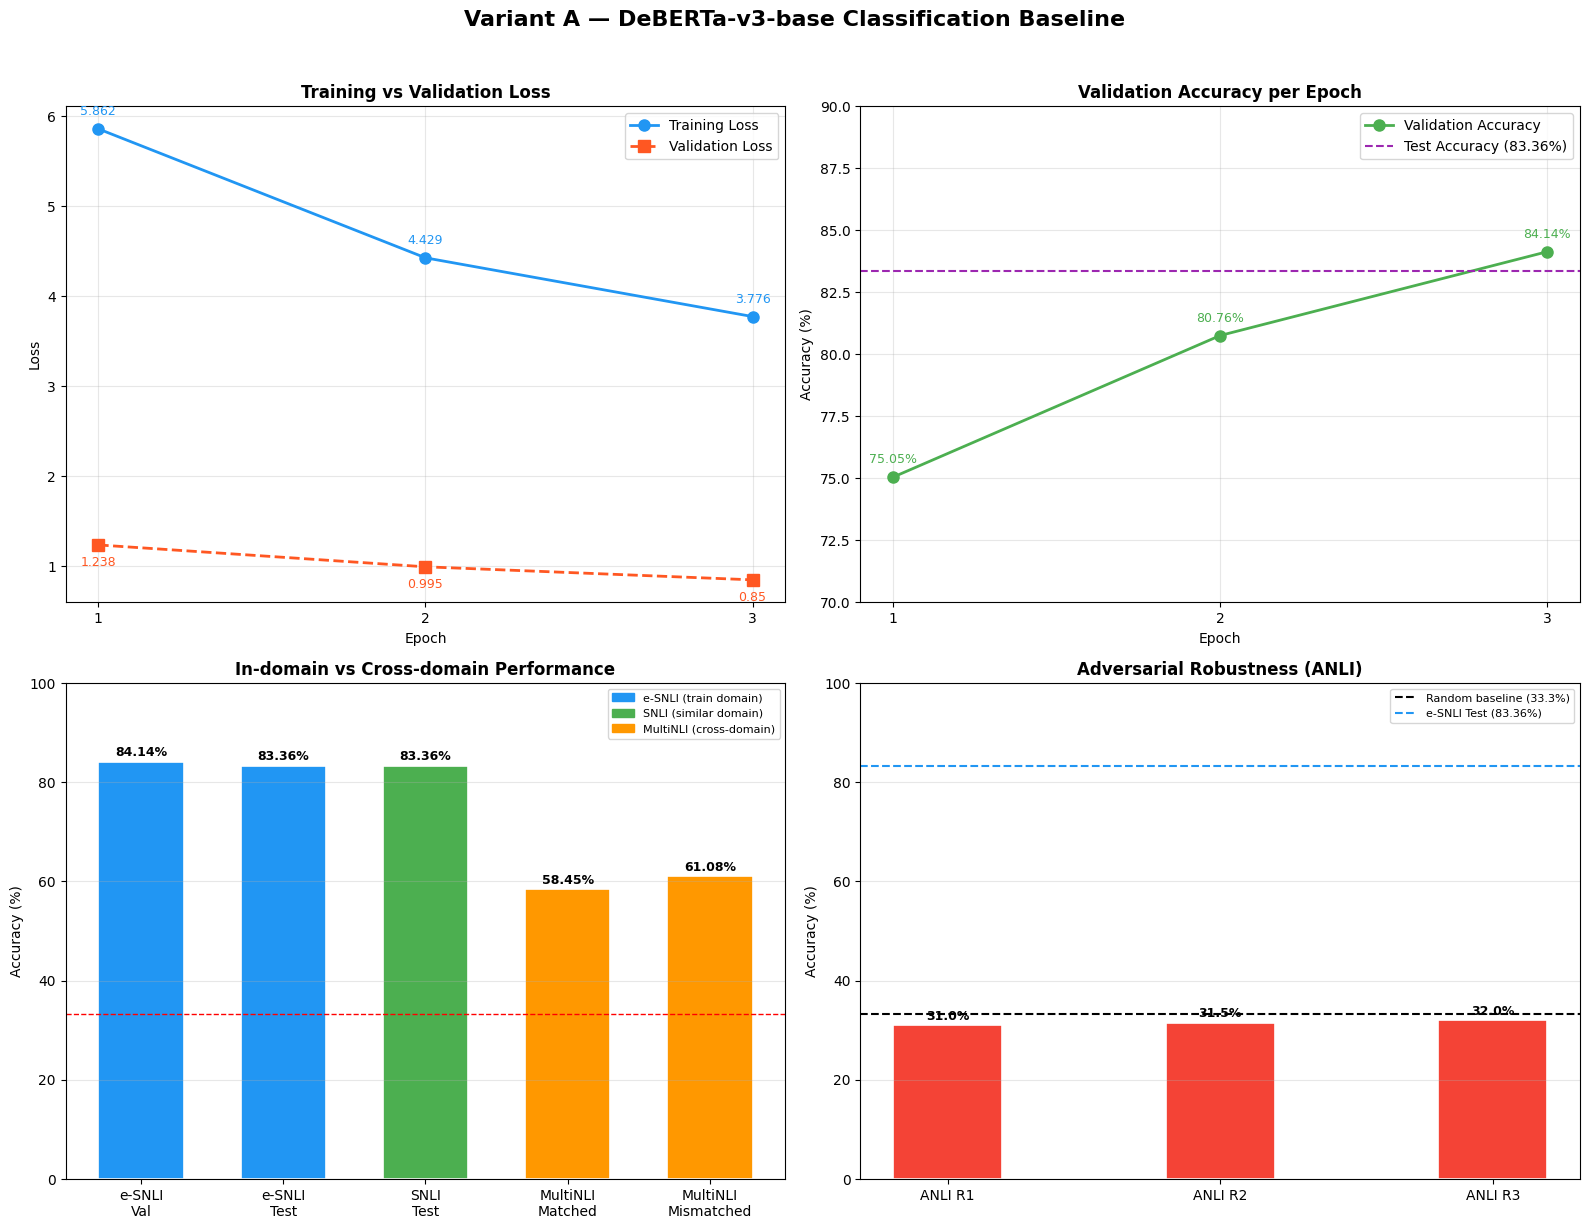

Plots saved to /kaggle/working/variant_a_plots.png!


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Training data
epochs     = [1, 2, 3]
train_loss = [5.862, 4.429, 3.776]
val_loss   = [1.238, 0.995, 0.850]
val_acc    = [75.05, 80.76, 84.14]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Variant A — DeBERTa-v3-base Classification Baseline",
             fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Loss curves ──────────────────────────────────────────────
axes[0,0].plot(epochs, train_loss, 'o-', color='#2196F3', linewidth=2,
               markersize=8, label='Training Loss')
axes[0,0].plot(epochs, val_loss, 's--', color='#FF5722', linewidth=2,
               markersize=8, label='Validation Loss')
axes[0,0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].set_xticks(epochs)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
for i, (tl, vl) in enumerate(zip(train_loss, val_loss)):
    axes[0,0].annotate(f'{tl}', (epochs[i], tl), textcoords="offset points",
                       xytext=(0, 10), ha='center', fontsize=9, color='#2196F3')
    axes[0,0].annotate(f'{vl}', (epochs[i], vl), textcoords="offset points",
                       xytext=(0, -15), ha='center', fontsize=9, color='#FF5722')

# ── Plot 2: Accuracy curve ───────────────────────────────────────────
axes[0,1].plot(epochs, val_acc, 'o-', color='#4CAF50', linewidth=2,
               markersize=8, label='Validation Accuracy')
axes[0,1].axhline(y=83.36, color='#9C27B0', linestyle='--', linewidth=1.5,
                  label='Test Accuracy (83.36%)')
axes[0,1].set_title('Validation Accuracy per Epoch', fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].set_xticks(epochs)
axes[0,1].set_ylim(70, 90)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
for i, acc in enumerate(val_acc):
    axes[0,1].annotate(f'{acc}%', (epochs[i], acc), textcoords="offset points",
                       xytext=(0, 10), ha='center', fontsize=9, color='#4CAF50')

# ── Plot 3: In-domain vs Cross-domain ───────────────────────────────
benchmarks1 = ['e-SNLI\nVal', 'e-SNLI\nTest', 'SNLI\nTest',
                'MultiNLI\nMatched', 'MultiNLI\nMismatched']
accuracies1  = [84.14, 83.36, 83.36, 58.45, 61.08]
colors1      = ['#2196F3', '#2196F3', '#4CAF50', '#FF9800', '#FF9800']

bars1 = axes[1,0].bar(benchmarks1, accuracies1, color=colors1,
                      edgecolor='white', linewidth=1.2, width=0.6)
axes[1,0].set_title('In-domain vs Cross-domain Performance', fontweight='bold')
axes[1,0].set_ylabel('Accuracy (%)')
axes[1,0].set_ylim(0, 100)
axes[1,0].axhline(y=33.33, color='red', linestyle='--', linewidth=1,
                  label='Random baseline (33.3%)')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars1, accuracies1):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{acc}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

blue_patch  = mpatches.Patch(color='#2196F3', label='e-SNLI (train domain)')
green_patch = mpatches.Patch(color='#4CAF50', label='SNLI (similar domain)')
orange_patch = mpatches.Patch(color='#FF9800', label='MultiNLI (cross-domain)')
axes[1,0].legend(handles=[blue_patch, green_patch, orange_patch], fontsize=8)

# ── Plot 4: Adversarial performance ─────────────────────────────────
benchmarks2 = ['ANLI R1', 'ANLI R2', 'ANLI R3']
accuracies2  = [31.00, 31.50, 32.00]

bars2 = axes[1,1].bar(benchmarks2, accuracies2, color='#F44336',
                      edgecolor='white', linewidth=1.2, width=0.4)
axes[1,1].axhline(y=33.33, color='black', linestyle='--', linewidth=1.5,
                  label='Random baseline (33.3%)')
axes[1,1].axhline(y=83.36, color='#2196F3', linestyle='--', linewidth=1.5,
                  label='e-SNLI Test (83.36%)')
axes[1,1].set_title('Adversarial Robustness (ANLI)', fontweight='bold')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].set_ylim(0, 100)
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars2, accuracies2):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{acc}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/variant_a_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved to /kaggle/working/variant_a_plots.png!")